# 01 - Cross-venue divergences and flagged anomalies

Exploratory look at the paired Polymarket/Kalshi FOMC contracts, then the two detectors: Isolation Forest scores and the joint price-AND-liquidity consensus rule. All scores are walk-forward (fitted on earlier meetings only).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.width', 200)
an = pd.read_parquet(ROOT / 'data' / 'sample' / 'anomalies.parquet')
print(an.shape, an.pair_id.nunique(), 'pairs', an.meeting.nunique(), 'meetings')
an[['abs_div', 'logit_div', 'spread_kalshi', 'volume_poly', 'volume_kalshi']].describe().round(4)

(4324, 32) 63 pairs 20 meetings


,abs_div,logit_div,spread_kalshi,volume_poly,volume_kalshi
count,4324.0000,4324.0000,2746.0000,4.324000e+03,4.324000e+03
mean,0.0101,-0.2490,0.0139,4.732435e+05,9.640037e+04
std,0.0085,0.4621,0.0128,9.093150e+05,2.495742e+05
min,0.0000,-1.6297,0.0100,0.000000e+00,0.000000e+00
25%,0.0055,-0.6982,0.0100,3.575736e+04,6.981016e+02
50%,0.0085,-0.2400,0.0100,1.553585e+05,9.770690e+03
75%,0.0120,0.0482,0.0100,4.884703e+05,8.383252e+04
max,0.0990,1.3499,0.2700,1.233929e+07,3.491735e+06


## How large are the divergences?
Most gaps are about one cent, comparable to the spread and fee.

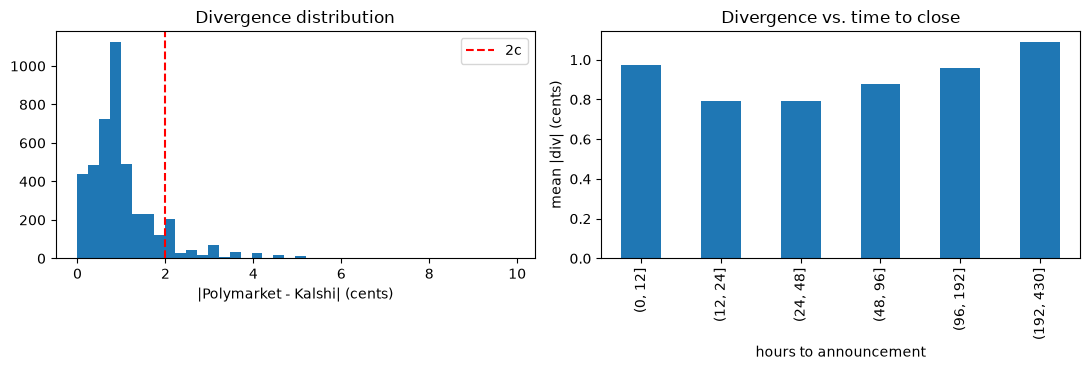

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(an.abs_div * 100, bins=40); ax[0].axvline(2, color='r', ls='--', label='2c')
ax[0].set(xlabel='|Polymarket - Kalshi| (cents)', title='Divergence distribution'); ax[0].legend()
b = an.assign(bin=pd.cut(an.hours_to_close, [0, 12, 24, 48, 96, 192, 430]))
b.groupby('bin', observed=True).abs_div.mean().mul(100).plot.bar(ax=ax[1])
ax[1].set(xlabel='hours to announcement', ylabel='mean |div| (cents)', title='Divergence vs. time to close')
plt.tight_layout(); plt.show()

## Detector counts
`if_flag` = top 5% Isolation-Forest score of the training data; `consensus` = price signal AND liquidity signal.

In [3]:
sc = an.dropna(subset=['if_score'])
pd.Series({'scored snapshots': len(sc), 'IF flagged': int(sc.if_flag.sum()),
           'price signal': int(sc.price_signal.astype(bool).sum()),
           'liquidity signal': int(sc.liquidity_signal.astype(bool).sum()),
           'consensus (both)': int(sc.consensus.astype(bool).sum()),
           '|div| >= 2c': int((sc.abs_div >= 0.02).sum())})

scored snapshots    3672
IF flagged            39
price signal         194
liquidity signal    2640
consensus (both)     175
|div| >= 2c          301
dtype: int64

## Are flagged divergences more persistent?
Label = the >=2c gap is still there, same sign and >= half size, 24h later. The counts per group matter as much as the rates: the samples are small.

In [4]:
lab = sc.dropna(subset=['persistent'])
rows = []
for name in ['if_flag', 'price_signal', 'liquidity_signal', 'consensus']:
    for val, g in lab.groupby(lab[name].astype(bool)):
        rows.append({'detector': name, 'flag': val, 'n': len(g), 'persistent_rate': round(g.persistent.mean(), 3)})
pd.DataFrame(rows)

,detector,flag,n,persistent_rate
0,if_flag,False,293,0.720
1,if_flag,True,4,0.250
2,price_signal,False,272,0.724
3,price_signal,True,25,0.600
4,liquidity_signal,False,41,0.463
5,liquidity_signal,True,256,0.754
6,consensus,False,278,0.716
7,consensus,True,19,0.684


In [5]:
top = sc[sc.consensus.astype(bool)].sort_values('abs_div', ascending=False).head(12)
top[['pair_id', 'hours_to_close', 'p_poly', 'p_kalshi', 'div', 'volume_poly', 'volume_kalshi', 'if_score', 'persistent']].round(3)

,pair_id,hours_to_close,p_poly,p_kalshi,div,volume_poly,volume_kalshi,if_score,persistent
1037,KXFEDDECISION-25JAN-H0,277.0,0.949,0.985,-0.036,264636.019,13119.56,0.520,1.0
1044,KXFEDDECISION-25JAN-H0,235.0,0.952,0.985,-0.032,178478.367,2193.75,0.506,0.0
1042,KXFEDDECISION-25JAN-H0,247.0,0.953,0.985,-0.032,115693.114,213.65,0.503,0.0
1041,KXFEDDECISION-25JAN-H0,253.0,0.956,0.985,-0.029,125186.112,213.65,0.508,1.0
1043,KXFEDDECISION-25JAN-H0,241.0,0.957,0.985,-0.028,137485.943,313.65,0.503,1.0
794,FEDDECISION-24NOV-H0,7.0,0.014,0.040,-0.026,281764.856,9528.42,0.601,NaN
977,KXFEDDECISION-25JAN-C25,205.0,0.008,0.030,-0.022,91983.435,9817.77,0.540,1.0
2222,KXFEDDECISION-25OCT-C25,79.0,0.986,0.965,0.022,2141594.390,62960.11,0.470,1.0
1047,KXFEDDECISION-25JAN-H0,217.0,0.964,0.985,-0.021,487788.679,3832.91,0.487,0.0
1413,KXFEDDECISION-25MAY-C26,181.0,0.009,0.030,-0.021,64285.504,40890.84,0.484,1.0


## Example: a flagged pair over time

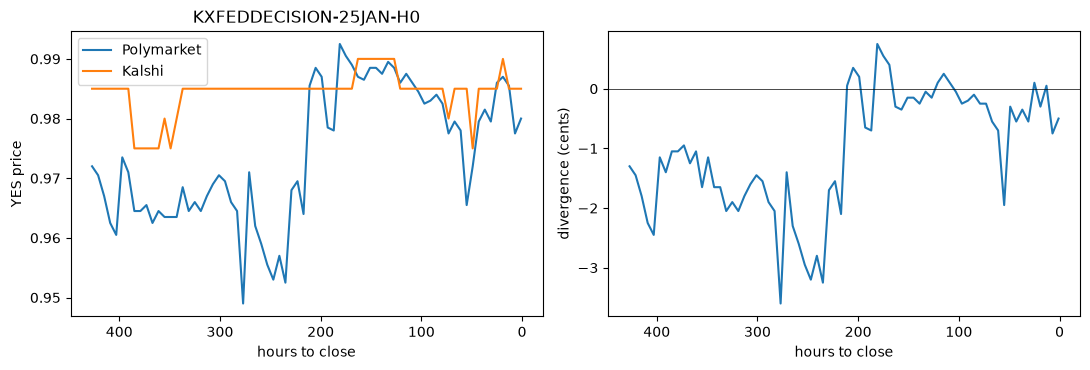

In [6]:
pid = top.pair_id.iloc[0]
g = an[an.pair_id == pid].sort_values('hours_to_close', ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(g.hours_to_close, g.p_poly, label='Polymarket'); ax[0].plot(g.hours_to_close, g.p_kalshi, label='Kalshi')
ax[0].invert_xaxis(); ax[0].set(title=pid, xlabel='hours to close', ylabel='YES price'); ax[0].legend()
ax[1].plot(g.hours_to_close, g['div'] * 100); ax[1].axhline(0, color='k', lw=.5); ax[1].invert_xaxis()
ax[1].set(xlabel='hours to close', ylabel='divergence (cents)'); plt.tight_layout(); plt.show()